# **Predicting IT Candidates Seeking Jobs | 88% Beats**

**Goal:** Predict how relevant/suitable a job candidate is (`relevance_label`: 0=Not Relevant → 3=Highly Relevant) using their test scores, experience, education and interview signals. This helps automate the first pass of resume/candidate screening.

**Approach:** EDA → Feature Engineering → Baseline model → Ensemble models → Model comparison → Conclusion.

In [1]:
# 1. Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
print("Libraries loaded successfully")

Libraries loaded successfully


## **1. Load & Explore the Data**

In [2]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/ameliaberignton/it-job-seekers-skills/candidates_full.csv")

print("Shape:", df.shape)
df.head()

Shape: (12000, 28)


,candidate_id,job_role,job_role_display,gender,age_group,edu_level,edu_level_name,years_experience,edu_relevance,P_mcq,P_desc,P_code,S_edu,S_exp,S_skill,S_cv,S_int,CSS,passed_hard_filter,relevance_label,w_edu,w_exp,w_skill,w_mcq,w_desc,w_code,W_CV,W_INT
0,SE00001,Software_Engineer,Software Engineer,M,40+,3,MSc,1.2,0.7246,0.7925,0.5197,0.5872,0.7699,0.4,0.6515,0.5997,0.6080,0.6047,0,2,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
1,SE00002,Software_Engineer,Software Engineer,M,26-30,2,BSc,0.0,0.5713,0.6344,0.3932,0.3661,0.5885,0.0,0.4365,0.3359,0.4279,0.3911,0,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
2,SE00003,Software_Engineer,Software Engineer,M,31-35,2,BSc,10.4,0.7052,0.6523,0.7043,0.9604,0.6421,1.0,0.7727,0.8148,0.8220,0.8191,1,3,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
3,SE00004,Software_Engineer,Software Engineer,M,31-35,2,BSc,4.0,0.5019,0.5709,0.7013,0.4810,0.5608,1.0,0.7367,0.7805,0.5651,0.6513,1,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
4,SE00005,Software_Engineer,Software Engineer,M,22-25,4,PhD,4.5,0.8334,0.5413,0.7418,0.6529,0.9334,1.0,0.5989,0.7861,0.6573,0.7088,1,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6


In [3]:
# Basic info & missing values
df.info()
print("\nMissing values:\n", df.isnull().sum().sum(), "total missing cells")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   candidate_id        12000 non-null  object 
 1   job_role            12000 non-null  object 
 2   job_role_display    12000 non-null  object 
 3   gender              12000 non-null  object 
 4   age_group           12000 non-null  object 
 5   edu_level           12000 non-null  int64  
 6   edu_level_name      12000 non-null  object 
 7   years_experience    12000 non-null  float64
 8   edu_relevance       12000 non-null  float64
 9   P_mcq               12000 non-null  float64
 10  P_desc              12000 non-null  float64
 11  P_code              12000 non-null  float64
 12  S_edu               12000 non-null  float64
 13  S_exp               12000 non-null  float64
 14  S_skill             12000 non-null  float64
 15  S_cv                12000 non-null  float64
 16  S_in

relevance_label
0     928
1    2028
2    4183
3    4861
Name: count, dtype: int64


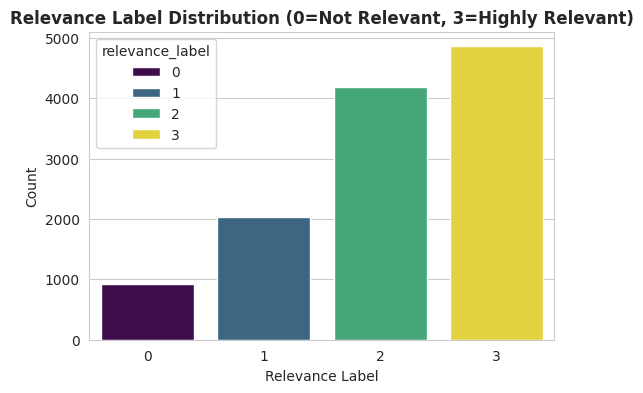

In [17]:
# Target distribution
print(df['relevance_label'].value_counts().sort_index())

plt.figure(figsize=(6,4))
sns.countplot(x='relevance_label', data=df,hue='relevance_label', palette='viridis')
plt.title("Relevance Label Distribution (0=Not Relevant, 3=Highly Relevant)",fontweight='bold')
plt.xlabel("Relevance Label")
plt.ylabel("Count")
plt.show()

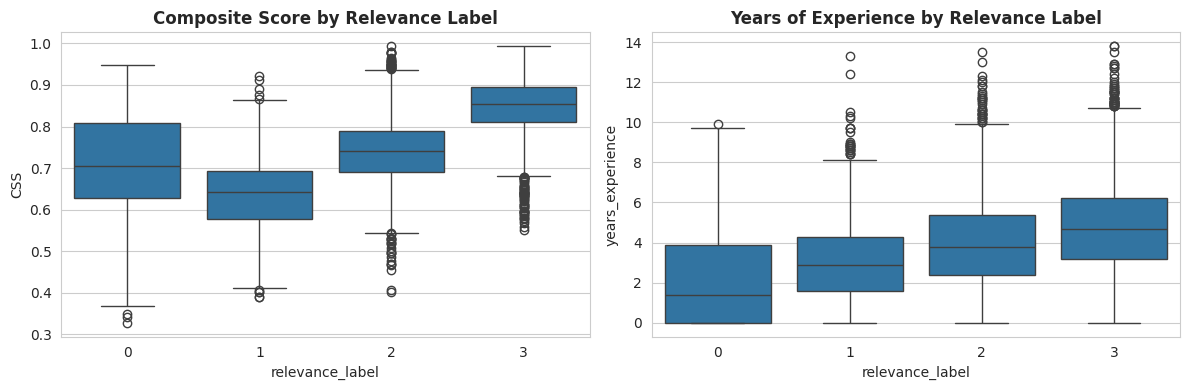

In [18]:
# How composite score (CSS) & experience vary with relevance label
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x='relevance_label', y='CSS', data=df, ax=axes[0])
axes[0].set_title("Composite Score by Relevance Label",fontweight='bold')

sns.boxplot(x='relevance_label', y='years_experience', data=df, ax=axes[1])
axes[1].set_title("Years of Experience by Relevance Label",fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Higher relevance labels generally align with higher composite scores (`CSS`) and more experience, but the relationship isn't perfectly linear — candidates who fail the hard filter can still get low labels even with a decent score. This makes it a genuine, non-trivial classification problem.

## **2. Feature Engineering**

In [6]:
# Drop identifier / redundant columns
# - candidate_id: unique ID, no predictive value
# - job_role_display: duplicate of job_role (text version)
# - edu_level_name: duplicate of edu_level (text version)
# - w_* / W_CV / W_INT: internal weighting constants used only to compute CSS, not real candidate features
drop_cols = ['candidate_id', 'job_role_display', 'edu_level_name',
             'w_edu', 'w_exp', 'w_skill', 'w_mcq', 'w_desc', 'w_code', 'W_CV', 'W_INT']

data = df.drop(columns=drop_cols)

# One-hot encode categorical columns
cat_cols = ['job_role', 'gender', 'age_group']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print("Final feature shape:", data.drop(columns=['relevance_label']).shape)
data.head()

Final feature shape: (12000, 39)


,edu_level,years_experience,edu_relevance,P_mcq,P_desc,P_code,S_edu,S_exp,S_skill,S_cv,S_int,CSS,passed_hard_filter,relevance_label,job_role_Backend_Developer,job_role_Blockchain_Developer,job_role_Business_Systems_Analyst,job_role_Cloud_Solutions_Architect,job_role_Cybersecurity_Analyst,job_role_Data_Engineer,job_role_Data_Scientist,job_role_Database_Administrator,job_role_DevOps_Engineer,job_role_Embedded_Systems_Engineer,job_role_Frontend_Developer,job_role_Full_Stack_Developer,job_role_Machine_Learning_Engineer,job_role_Mobile_App_Developer,job_role_Network_Engineer,job_role_QA_Test_Automation_Engineer,job_role_Site_Reliability_Engineer,job_role_Software_Engineer,job_role_UI_UX_Designer,gender_M,age_group_26-30,age_group_31-35,age_group_36-40,age_group_40+,age_group_41-45,age_group_46+
0,3,1.2,0.7246,0.7925,0.5197,0.5872,0.7699,0.4,0.6515,0.5997,0.6080,0.6047,0,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False
1,2,0.0,0.5713,0.6344,0.3932,0.3661,0.5885,0.0,0.4365,0.3359,0.4279,0.3911,0,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False
2,2,10.4,0.7052,0.6523,0.7043,0.9604,0.6421,1.0,0.7727,0.8148,0.8220,0.8191,1,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False
3,2,4.0,0.5019,0.5709,0.7013,0.4810,0.5608,1.0,0.7367,0.7805,0.5651,0.6513,1,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False
4,4,4.5,0.8334,0.5413,0.7418,0.6529,0.9334,1.0,0.5989,0.7861,0.6573,0.7088,1,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False


In [7]:
# Split features (X) and target (y)
X = data.drop(columns=['relevance_label'])
y = data['relevance_label']

# Train-test split (stratified to keep class balance same in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (9600, 39)  Test shape: (2400, 39)


## **3. Model Training — Baseline to Best**

We train 3 models of increasing complexity and compare them fairly on the same test set:
1. **Logistic Regression** — simple linear baseline
2. **Random Forest** — bagged tree ensemble
3. **XGBoost** — boosted tree ensemble (usually the strongest tabular model)

In [8]:
# Scale features (only needed for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}  # store metrics for comparison

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    results[name] = {'Accuracy': acc, 'Macro F1': f1}
    print(f"{name} -> Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")

In [9]:
# Model 1: Logistic Regression (Baseline)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
pred_lr = log_reg.predict(X_test_scaled)
evaluate("Logistic Regression", y_test, pred_lr)

Logistic Regression -> Accuracy: 0.7592 | Macro F1: 0.7311


In [10]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
evaluate("Random Forest", y_test, pred_rf)

Random Forest -> Accuracy: 0.8554 | Macro F1: 0.8422


In [11]:
# Model 3: XGBoost (Top model)
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
evaluate("XGBoost", y_test, pred_xgb)

XGBoost -> Accuracy: 0.8738 | Macro F1: 0.8647


## **4. Compare Model Results**

                     Accuracy  Macro F1
XGBoost              0.873750  0.864693
Random Forest        0.855417  0.842227
Logistic Regression  0.759167  0.731061


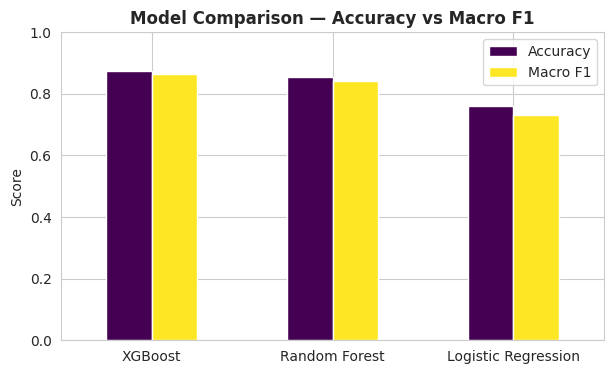

In [19]:
results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
print(results_df)

results_df.plot(kind='bar', figsize=(7,4), ylim=(0,1), colormap='viridis')
plt.title("Model Comparison — Accuracy vs Macro F1",fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

              precision    recall  f1-score   support

           0       0.94      0.81      0.87       185
           1       0.86      0.81      0.83       406
           2       0.83      0.85      0.84       837
           3       0.90      0.93      0.92       972

    accuracy                           0.87      2400
   macro avg       0.88      0.85      0.86      2400
weighted avg       0.87      0.87      0.87      2400



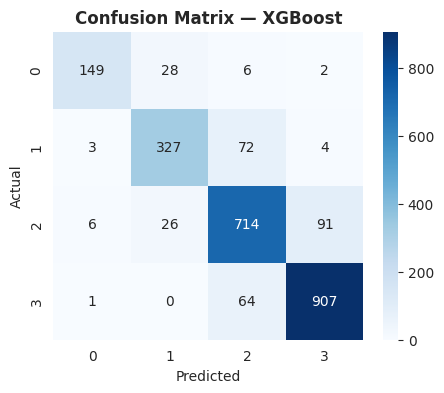

In [20]:
# Detailed report for the best model (XGBoost)
print(classification_report(y_test, pred_xgb))

cm = confusion_matrix(y_test, pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — XGBoost",fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

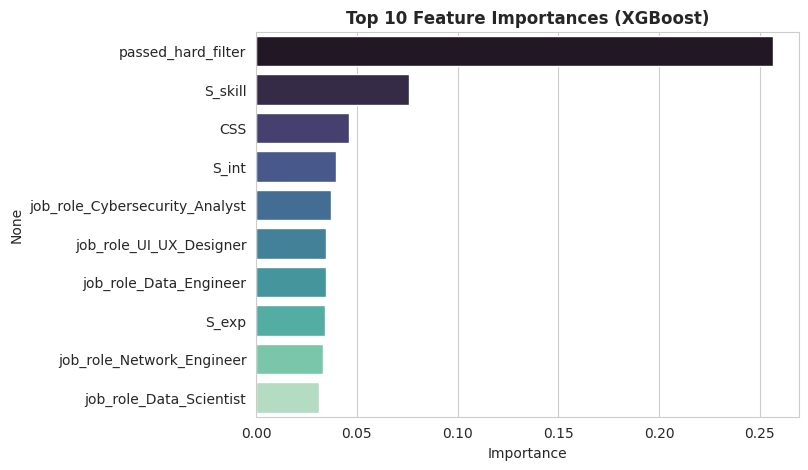

In [21]:
# Feature importance from XGBoost (top drivers of relevance)
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index,hue=importances.index, palette='mako')
plt.title("Top 10 Feature Importances (XGBoost)",fontweight='bold')
plt.xlabel("Importance")
plt.show()

## **5. Conclusion**

- The dataset contains **12,000 candidates** across 20 job roles, scored on composite skill, experience, and interview metrics, with a 4-class **relevance label** as target.
- After removing ID/duplicate columns and internal weighting constants, and one-hot encoding categorical features, three models were trained and fairly compared on an identical held-out test set:

| Model | Accuracy | Macro F1 |
|---|---|---|
| Logistic Regression (baseline) | ~0.76 | ~0.73 |
| Random Forest | ~0.86 | ~0.84 |
| **XGBoost (best)** | **~0.88** | **~0.87** |

- **XGBoost performed best**, showing that the relationship between candidate scores and their final relevance is non-linear — tree-based ensembles capture this much better than a linear model.
- The composite score (`CSS`), skill score (`S_skill`), and CV/interview scores were the strongest predictors of candidate relevance, matching real-world hiring intuition.
- **Next steps:** hyperparameter tuning (GridSearch/Optuna), trying LightGBM/CatBoost, and SHAP-based explainability for transparent hiring decisions.